<a href="https://colab.research.google.com/github/SHIVARAMAN15/BTech-Project-Reports/blob/main/ECG_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb neurokit2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


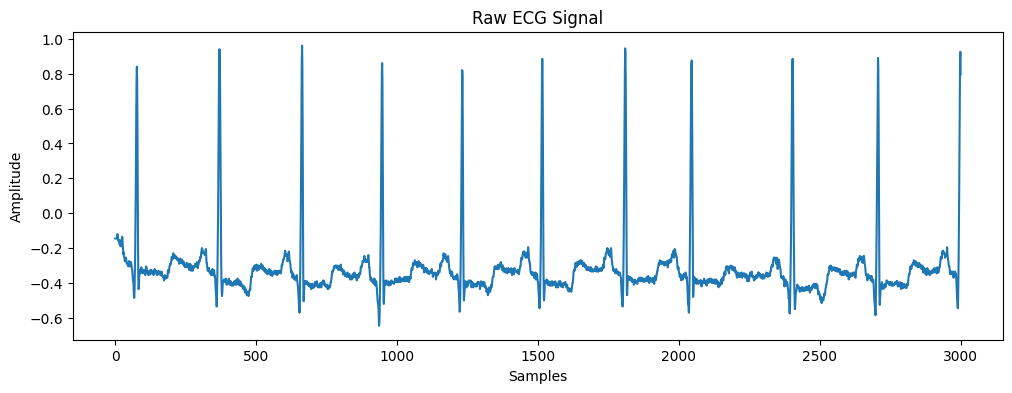

In [ ]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord('100', pn_dir='mitdb')
signal = record.p_signal[:,0]

plt.figure(figsize=(12,4))
plt.plot(signal[:3000])
plt.title("Raw ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

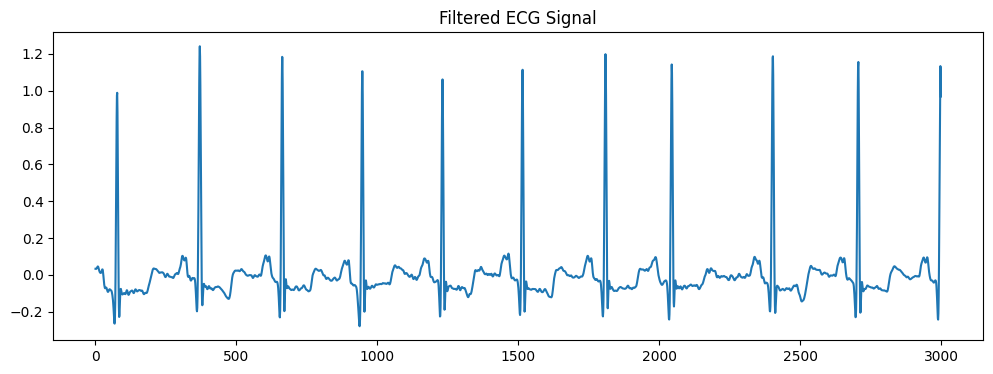

In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np

fs = 360

lowcut = 0.5
highcut = 40

b, a = butter(4, [lowcut/(fs/2), highcut/(fs/2)], btype='band')

filtered = filtfilt(b, a, signal)

plt.figure(figsize=(12,4))
plt.plot(filtered[:3000])
plt.title("Filtered ECG Signal")
plt.show()

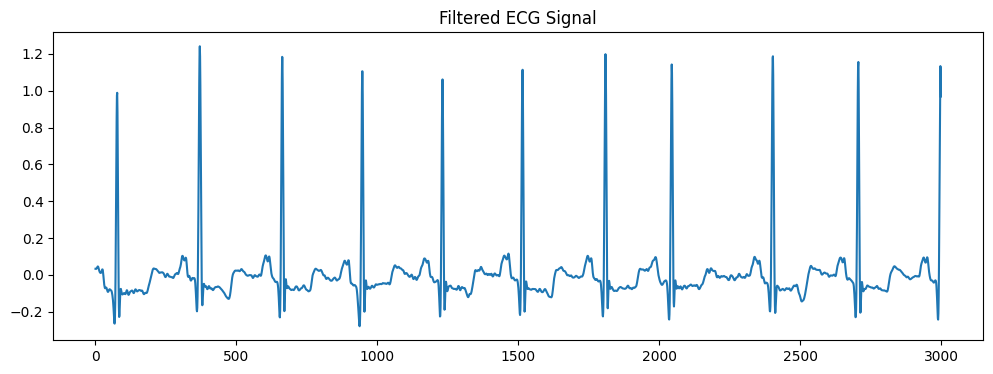

In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np

fs = 360

lowcut = 0.5
highcut = 40

b, a = butter(4, [lowcut/(fs/2), highcut/(fs/2)], btype='band')

filtered = filtfilt(b, a, signal)

plt.figure(figsize=(12,4))
plt.plot(filtered[:3000])
plt.title("Filtered ECG Signal")
plt.show()

/usr/local/lib/python3.12/dist-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(


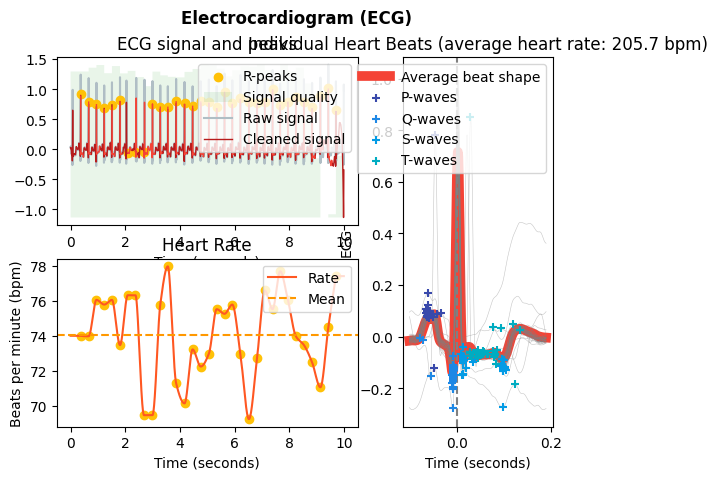

In [ ]:
segment = filtered[:10000]

signals, info = nk.ecg_process(
    segment,
    sampling_rate=360
)

nk.ecg_plot(signals)

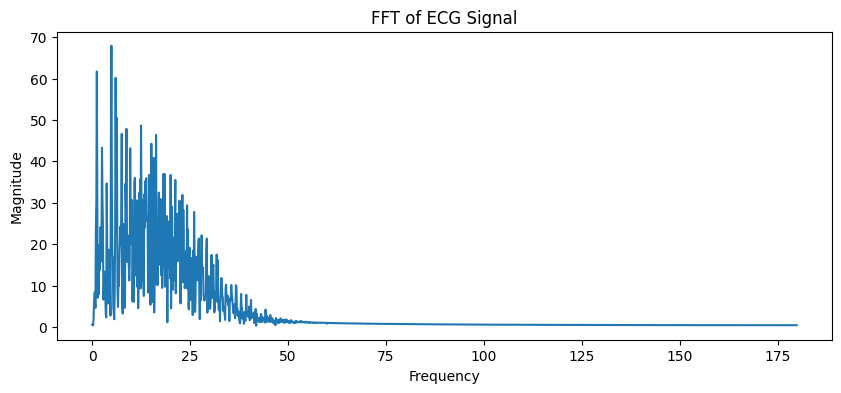

In [ ]:
from scipy.fft import fft, fftfreq

N = len(filtered[:3000])

yf = fft(filtered[:3000])
xf = fftfreq(N, 1/fs)

plt.figure(figsize=(10,4))
plt.plot(xf[:N//2], np.abs(yf[:N//2]))
plt.title("FFT of ECG Signal")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()